In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/tesla_trip_data.csv")

df.head()

,trip_id,speed_mph,outside_temp_f,hvac_on,elevation_gain_ft,distance_miles,energy_used_kwh,wh_per_mile
0,1,35,70,0,120,25,6.2,248
1,2,45,72,0,210,31,8.1,261
2,3,55,68,1,320,38,10.4,274
3,4,65,75,1,500,45,14.2,315
4,5,75,80,1,800,50,18.5,370


In [7]:
df["driving_type"] = df["speed_mph"].apply(
    lambda x: "Highway" if x >= 60 else "City"
)

df.head()

,trip_id,speed_mph,outside_temp_f,hvac_on,elevation_gain_ft,distance_miles,energy_used_kwh,wh_per_mile,driving_type
0,1,35,70,0,120,25,6.2,248,City
1,2,45,72,0,210,31,8.1,261,City
2,3,55,68,1,320,38,10.4,274,City
3,4,65,75,1,500,45,14.2,315,Highway
4,5,75,80,1,800,50,18.5,370,Highway


In [9]:
def classify_temp(temp):
    if temp < 50:
        return "Cold"
    elif temp < 80:
        return "Moderate"
    else:
        return "Hot"

df["temp_range"] = df["outside_temp_f"].apply(classify_temp)

df.head()

,trip_id,speed_mph,outside_temp_f,hvac_on,elevation_gain_ft,distance_miles,energy_used_kwh,wh_per_mile,driving_type,temp_range
0,1,35,70,0,120,25,6.2,248,City,Moderate
1,2,45,72,0,210,31,8.1,261,City,Moderate
2,3,55,68,1,320,38,10.4,274,City,Moderate
3,4,65,75,1,500,45,14.2,315,Highway,Moderate
4,5,75,80,1,800,50,18.5,370,Highway,Hot


In [11]:
grouped = df.groupby("driving_type")["wh_per_mile"].mean()

print(grouped)

driving_type
City       287.0
Highway    349.8
Name: wh_per_mile, dtype: float64


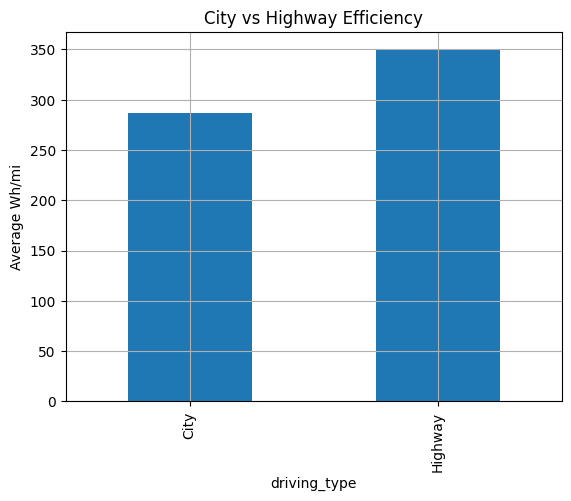

In [13]:
grouped.plot(kind="bar")

plt.ylabel("Average Wh/mi")
plt.title("City vs Highway Efficiency")
plt.grid(True)

plt.savefig("../graphs/city_vs_highway.png", dpi=300)
plt.show()

In [15]:
hvac_on = df[df["hvac_on"] == 1]
hvac_off = df[df["hvac_on"] == 0]

print("HVAC ON average:", hvac_on["wh_per_mile"].mean())
print("HVAC OFF average:", hvac_off["wh_per_mile"].mean())

HVAC ON average: 334.375
HVAC OFF average: 254.5


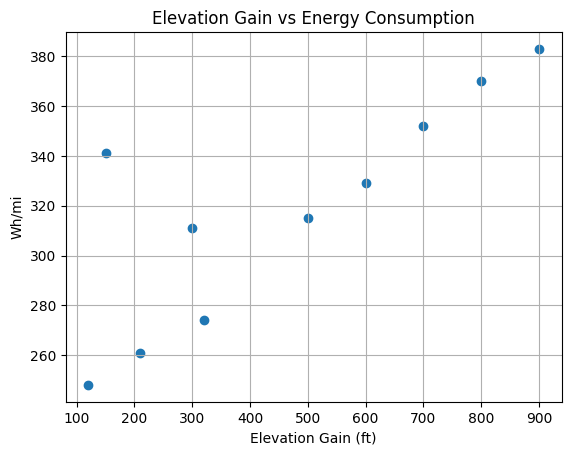

In [17]:
plt.scatter(df["elevation_gain_ft"], df["wh_per_mile"])

plt.xlabel("Elevation Gain (ft)")
plt.ylabel("Wh/mi")
plt.title("Elevation Gain vs Energy Consumption")
plt.grid(True)

plt.savefig("../graphs/elevation_vs_efficiency.png", dpi=300)
plt.show()

In [19]:
def efficiency_band(wh):
    if wh < 280:
        return "Efficient"
    elif wh < 340:
        return "Moderate"
    else:
        return "Inefficient"

df["efficiency_band"] = df["wh_per_mile"].apply(efficiency_band)

df.head()

,trip_id,speed_mph,outside_temp_f,hvac_on,elevation_gain_ft,distance_miles,energy_used_kwh,wh_per_mile,driving_type,temp_range,efficiency_band
0,1,35,70,0,120,25,6.2,248,City,Moderate,Efficient
1,2,45,72,0,210,31,8.1,261,City,Moderate,Efficient
2,3,55,68,1,320,38,10.4,274,City,Moderate,Efficient
3,4,65,75,1,500,45,14.2,315,Highway,Moderate,Moderate
4,5,75,80,1,800,50,18.5,370,Highway,Hot,Inefficient


In [21]:
band_counts = df["efficiency_band"].value_counts()

print(band_counts)

efficiency_band
Inefficient    4
Efficient      3
Moderate       3
Name: count, dtype: int64


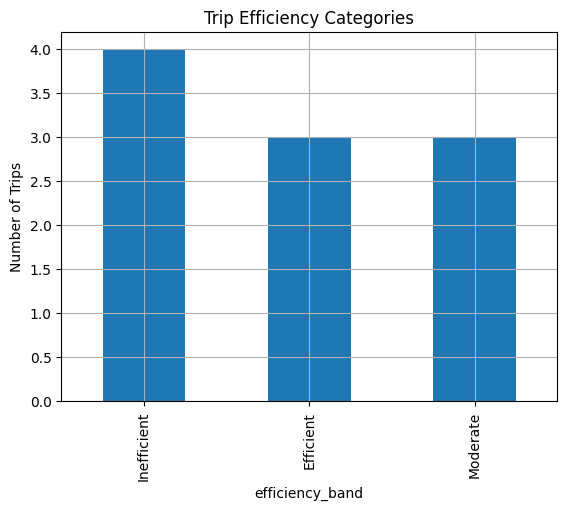

In [23]:
band_counts.plot(kind="bar")

plt.ylabel("Number of Trips")
plt.title("Trip Efficiency Categories")
plt.grid(True)

plt.savefig("../graphs/efficiency_categories.png", dpi=300)
plt.show()

In [24]:
correlation = df.corr(numeric_only=True)

print(correlation)

                    trip_id  speed_mph  outside_temp_f   hvac_on  \
trip_id            1.000000   0.393893        0.049890  0.696311   
speed_mph          0.393893   1.000000        0.173703  0.530330   
outside_temp_f     0.049890   0.173703        1.000000 -0.102356   
hvac_on            0.696311   0.530330       -0.102356  1.000000   
elevation_gain_ft  0.549781   0.923862       -0.065808  0.554574   
distance_miles     0.410138   0.996403        0.200771  0.558014   
energy_used_kwh    0.553116   0.959051        0.057770  0.633269   
wh_per_mile        0.738830   0.620084       -0.240182  0.735379   

                   elevation_gain_ft  distance_miles  energy_used_kwh  \
trip_id                     0.549781        0.410138         0.553116   
speed_mph                   0.923862        0.996403         0.959051   
outside_temp_f             -0.065808        0.200771         0.057770   
hvac_on                     0.554574        0.558014         0.633269   
elevation_gain_ft     

## Findings

1. Highway driving conditions produced higher average Wh/mi than city driving.

2. HVAC usage appears to increase energy consumption, especially during colder trips.

3. Elevation gain showed a positive relationship with energy use.

4. Higher speeds strongly correlated with increased Wh/mi, likely due to aerodynamic drag increasing with velocity.

5. Temperature and HVAC operation together may significantly affect battery efficiency and overall range.